TV أرقامه كبيرة (scale effect)
correlation مش بيقيس التأثير
ratio مش بيقيس التأثير
فيه تداخل مع قنوات تانية

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

In [3]:
data = pd.read_csv(r'Advertising (1).csv')

In [4]:
data.head(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
data = data.drop('Unnamed: 0', axis=1)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
data.dropna(inplace=True)

In [10]:
data.drop_duplicates(inplace=True)

<Figure size 1000x600 with 0 Axes>

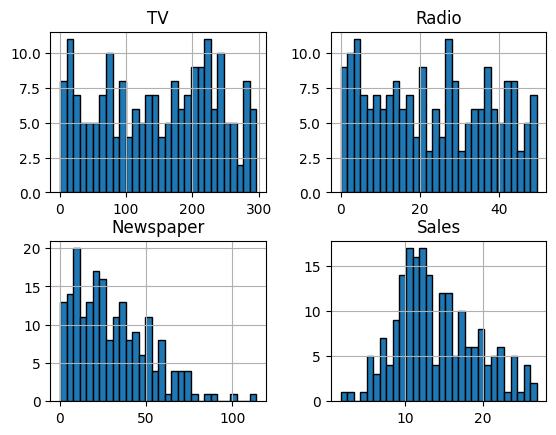

In [11]:
plt.figure(figsize=(10,6))
data.hist(bins=30, edgecolor='black')
plt.show()

In [12]:
df = data.copy()

### Diminishing Returns

In [13]:
corr = data[['TV', 'Radio', 'Newspaper', 'Sales']].corr()
fig = px.imshow(
    corr , text_auto=True, 
                title="Correlation Heatmap: Who drives Sales?")
fig.show()


In [14]:
data['tv_to_sales_ratio']        = data['TV']        / data['Sales']
data['radio_to_sales_ratio']     = data['Radio']     / data['Sales']
data['newspaper_to_sales_ratio'] = data['Newspaper'] / data['Sales']

data['sales_level'] = pd.qcut(data['Sales'], q=4, labels=['Low','Medium_Low','Medium_High','High'])

ratio_analysis = data.groupby('sales_level')[[
    'tv_to_sales_ratio','radio_to_sales_ratio','newspaper_to_sales_ratio'
]].mean()

print('✅ ratio_analysis ready')
ratio_analysis.round(2)

✅ ratio_analysis ready


C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\1522067698.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_analysis = data.groupby('sales_level')[[


,tv_to_sales_ratio,radio_to_sales_ratio,newspaper_to_sales_ratio
sales_level,,,
Low,5.02,2.58,3.45
Medium_Low,11.99,1.24,2.51
Medium_High,11.54,1.61,1.84
High,10.68,1.77,1.80


In [15]:
fig = px.box (
    data,
    x = 'sales_level', 
    y = ['tv_to_sales_ratio', 'radio_to_sales_ratio', 'newspaper_to_sales_ratio'], 
    title = 'Distribution of Advertising to Sales Ratio by Sales Level', 
    labels = {'sales_level': 'Sales Level', 'value': 'Ratio (Spending / Sales)'}, 
    color_discrete_sequence = ['#636EFA', '#EF553B', '#00CC96'] )

fig.update_layout(
    xaxis_title = 'Sales Level',
    yaxis_title = 'Average Advertising to Sales Ratio',
    legend_title = 'Advertising Medium',
    title_font_size = 20,
    title_x = 0.5) 
fig.show() 

In [16]:
%pip install statsmodels

df_melted = data.melt(id_vars = ['Sales'] , 
                    value_vars = ['tv_to_sales_ratio' , 'radio_to_sales_ratio' , 'newspaper_to_sales_ratio'] , 
                    var_name = 'Channel' , value_name = 'Ratio')  
fig = px.scatter(df_melted , x = 'Sales' , y = 'Ratio' , color = 'Channel' ,  trendline="lowess",
                title = 'Advertising to Sales Ratio vs Sales' , 
                labels = {'Sales': 'Sales', 'Ratio': 'Advertising to Sales Ratio'}, 
                color_discrete_sequence = ['#636EFA', '#EF553B', '#00CC96']) 
fig.update_layout( 
    title_font_size = 20,
    title_x = 0.5) 
fig.show()

Note: you may need to restart the kernel to use updated packages.


In [17]:
data['Tv_radio_intecreation'] = data['TV'] * data['Radio'] 
fig = px.scatter(data , x = 'Sales' , y = 'Tv_radio_intecreation' , trendline="lowess",
                title = 'Interaction of TV and Radio Spending vs Sales' , 
                labels = {'Sales': 'Sales', 'Tv_radio_intecreation': 'TV * Radio Spending'}, 
                color_discrete_sequence = ['#636EFA']) 
fig.update_layout( 
    title_font_size = 20, 
    title_x = 0.5) 
fig.show()

In [18]:
data['TV'].corr(data['Sales'])
print("Correlation between TV advertising and Sales:", data['TV'].corr(data['Sales']))

Correlation between TV advertising and Sales: 0.7822244248616066


In [19]:
print("Correlation Between Radio adversting and sales " , data['Radio'].corr(data['Sales']))

Correlation Between Radio adversting and sales  0.5762225745710553


In [20]:
print(data['Tv_radio_intecreation'].corr(data['Sales']))

0.963932045992048


In [21]:
fig = px.scatter(
    data , 
    x = 'TV' , 
    y = 'Sales' , 
    trendline="lowess" , 
    title = "Tv vs Sales " , 
    labels = {'Sales': 'Sales', 'TV': 'TV'}, 
    color_discrete_sequence = ['#636EFA']) 
fig.update_layout(
    title_font_size = 20, 
    title_x = 0.5) 
fig.show() 

fig= px.scatter(
    data , 
    x = 'Radio' , 
    y = 'Sales' , 
    trendline="lowess" , 
    title = 'Radio VS Sales' , 
    labels = {'Sales': 'Sales', 'Radio': 'Radio'}, 
    color_discrete_sequence = ['#636EFA']) 
fig.update_layout(
    title_font_size = 20, 
    title_x = 0.5) 
fig.show() 

In [22]:
data['Tv_Newspaper_interaction'] = data['TV'] * data['Newspaper']
fig = px.scatter(
    data , 
    x = 'Tv_Newspaper_interaction' , 
    y = 'Sales' , 
    trendline="lowess" , 
    title = 'Interaction of TV and Newspaper Spending vs Sales' ,
    labels = {'Sales': 'Sales', 'Tv_Newspaper_interaction': 'TV * Newspaper Spending'},
    color_discrete_sequence = ['#636EFA'])
fig.update_layout(
    title_font_size = 20, 
    title_x = 0.5) 
fig.show()

In [23]:
print("Correlation between TV and Newspaper interaction and Sales:", data['Tv_Newspaper_interaction'].corr(data['Sales']))

Correlation between TV and Newspaper interaction and Sales: 0.618533380722841


In [24]:
print("Correlation between newspaper interaction and sales " , data['Newspaper'].corr(data['Sales']))

Correlation between newspaper interaction and sales  0.22829902637616534


In [25]:
fig = px.scatter (
    data , 
    x = 'Newspaper' , 
    y = 'Sales' , 
    trendline = 'lowess' , 
    title = "Newspaper Vs Sales" , 
    labels = {'Sales': 'Sales', 'Newspaper': 'Newspaper'},
    color_discrete_sequence = ['#636EFA'])
fig.update_layout(
    title_font_size = 20, 
    title_x = 0.5) 
fig.show()

In [26]:
data['Radio_newspaper_interaction'] = data['Radio'] * data['Newspaper'] 
fig = px.scatter(
    data , 
    x = 'Radio_newspaper_interaction' , 
    y = 'Sales' , 
    trendline="lowess" , 
    title = 'Interaction of Radio and Newspaper Spending vs Sales' ,
    labels = {'Sales': 'Sales', 'Radio_Newspaper_interaction': 'Radio * Newspaper Spending'},
    color_discrete_sequence = ['#636EFA'])
fig.update_layout(
    title_font_size = 20, 
    title_x = 0.5) 
fig.show()

In [27]:
print("Correlation between newspaper and radio with sales" , data['Radio_newspaper_interaction'].corr(data['Sales'])) 

Correlation between newspaper and radio with sales 0.4158925951571856


In [28]:
fig = px.scatter_3d(data, x='TV', y='Radio', z='Sales',
                     title='TV & Radio Interaction on Sales') 
fig.show()

In [29]:
data['TV_Range'] = pd.qcut(data['TV'], q=3, labels=['Low', 'Medium', 'High'])
analysis = data.groupby('TV_Range')['Sales'].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\3287016065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = data.groupby('TV_Range')['Sales'].mean()


In [30]:
fig = px.bar(
    analysis.reset_index(name='Mean_Sales'),
    x='TV_Range',
    y='Mean_Sales',
    text_auto= '.2f',
    title = "Tv range mean sales" , 
    color_discrete_sequence=["#0A0A0A"])
fig.update_layout(
    title_font_size=20,
    title_x=0.5)
fig.show()

"TV advertising shows a consistent and stable impact on sales across all spend levels. The increase from Low to Medium (approx. 4.2 units) is very similar to the increase from Medium to High (approx. 4 units). This linear growth indicates that we haven't reached the saturation point yet, making TV a highly reliable and great option for driving sales growth."

In [31]:
data['Newspaper_Range'] = pd.qcut(data['Newspaper'] , q = 3 ,labels=['Low', 'Medium', 'High']) 
analysis_newspaper = data.groupby('Newspaper_Range')['Sales'].mean()
fig= px.bar(
    analysis_newspaper.reset_index(name='Mean_Sales'),  
    x = 'Newspaper_Range' ,  
    y='Mean_Sales',
    title = "newspaper range mean sales" , 
    text_auto= '.2f',
    color_discrete_sequence=["#0A0A0A"])
fig.update_layout(
    title_font_size=20,
    title_x=0.5)
fig.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\3785295113.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_newspaper = data.groupby('Newspaper_Range')['Sales'].mean()


In [32]:
data['Radio_Range'] = pd.qcut(data['Radio'] , q = 3 ,labels=['Low', 'Medium', 'High']) 
analysis_newspaper = data.groupby('Radio_Range')['Sales'].mean()
fig= px.bar(
    analysis_newspaper.reset_index(name='Mean_Sales'),  
    x = 'Radio_Range' ,  
    y='Mean_Sales',
    title = "Radio range mean sales" , 
    text_auto= '.2f',
    color_discrete_sequence=["#0A0A0A"])
fig.update_layout(
    title_font_size=20,
    title_x=0.5)
fig.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\752048147.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_newspaper = data.groupby('Radio_Range')['Sales'].mean()


In [33]:
marginal_data = [] 

for ch in ['TV', 'Radio', 'Newspaper']:
    data[ch + '_Range'] = pd.qcut(data[ch], q=3, labels=['Low', 'Medium', 'High'])
    grp = data.groupby(ch + '_Range')['Sales'].mean().sort_index()
    vals = grp.values

    marginal_data.append({
        'Channel': ch,
        'Transition': 'Low -> Medium',
        'Marginal Return': round(vals[1] - vals[0], 2)
    })
    marginal_data.append({
        'Channel': ch,
        'Transition': 'Medium -> High',
        'Marginal Return': round(vals[2] - vals[1], 2)
    })

mdf = pd.DataFrame(marginal_data)

fig = px.bar(
    mdf,
    x='Channel',
    y='Marginal Return',
    color='Transition',
    barmode='group',
    title="Diminishing Returns — Marginal Sales per Spend Range",
    text_auto='.2f'
)

fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(title_x=0.5, title_font_size=18, height=600)
fig.show()

for ch in ['TV', 'Radio', 'Newspaper']:
    sub = mdf[mdf['Channel'] == ch]
    low_med = sub[sub['Transition'] == 'Low -> Medium']['Marginal Return'].values[0]
    med_hig = sub[sub['Transition'] == 'Medium -> High']['Marginal Return'].values[0]

    diff = med_hig - low_med
    status = '✅ There is no saturation' if diff >= 0 else '⚠️ Diminishing Returns exist'
    print(f'  {ch:12s}: Low→Med={low_med:+.2f} | Med→High={med_hig:+.2f}  →  {status}')

C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\1762871073.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby(ch + '_Range')['Sales'].mean().sort_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\1762871073.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby(ch + '_Range')['Sales'].mean().sort_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_31972\1762871073.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

  TV          : Low→Med=+5.32 | Med→High=+3.90  →  ⚠️ Diminishing Returns exist
  Radio       : Low→Med=+3.44 | Med→High=+3.37  →  ⚠️ Diminishing Returns exist
  Newspaper   : Low→Med=-0.47 | Med→High=+3.49  →  ✅ There is no saturation


### Impact Analysis

In [34]:
from sklearn.linear_model import LinearRegression 

x = data[['TV']] 
y = data['Sales'] 
model_tv = LinearRegression()
model_tv.fit(x, y) 
print("TV Impact on Sales : ", model_tv.coef_[0]) 

x = data[['Radio']] 
y = data['Sales'] 
model_radio = LinearRegression()  
model_radio.fit(x, y)
print("Radio Impact on Sales: ", model_radio.coef_[0]) 

x = data[['Newspaper']] 
y = data['Sales'] 
model_news = LinearRegression()
model_news.fit(x, y)
print("Newspaper Impact on Sales : ", model_news.coef_[0]) 


TV Impact on Sales :  0.04753664043301975
Radio Impact on Sales:  0.20249578339243965
Newspaper Impact on Sales :  0.05469309847227336


In [35]:
x = data[['TV' , 'Newspaper' , 'Radio']] 
y = data['Sales'] 
model = LinearRegression() 

model.fit(x, y) 
print("Coefficients for TV, Newspaper, Radio on Sales:", model.coef_) 

results = pd.DataFrame({
    'TV': [model.coef_[0]],
    'Newspaper': [model.coef_[1]],
    'Radio': [model.coef_[2]]
})
print(results)

Coefficients for TV, Newspaper, Radio on Sales: [ 0.04576465 -0.00103749  0.18853002]
         TV  Newspaper    Radio
0  0.045765  -0.001037  0.18853


In [36]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
x_scaled = scaler.fit_transform(data[['TV' , 'Newspaper' , 'Radio']]) 

model.fit(x_scaled,y) 
results = pd.DataFrame({
    'TV': [model.coef_[0]],
    'Newspaper': [model.coef_[1]],
    'Radio': [model.coef_[2]]
})
print(results)

         TV  Newspaper     Radio
0  3.919254  -0.022539  2.792063


In [37]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
x_scaled = scaler.fit_transform(data[['Tv_radio_intecreation' , 'Tv_Newspaper_interaction' , 'Radio_newspaper_interaction']]) 

model.fit(x_scaled,y) 
results = pd.DataFrame({
    'Tv_radio_intecreation': [model.coef_[0]],
    'Tv_Newspaper_interaction': [model.coef_[1]],
    'Radio_newspaper_interaction': [model.coef_[2]]
})
print(results)

   Tv_radio_intecreation  Tv_Newspaper_interaction  \
0               4.928952                  0.637123   

   Radio_newspaper_interaction  
0                    -0.597873  


In [38]:
import plotly.graph_objects as go 

scaler = StandardScaler()
X_sc   = scaler.fit_transform(data[['TV','Radio','Newspaper']])
model  = LinearRegression().fit(X_sc, data['Sales'])

channels = ['TV', 'Radio', 'Newspaper']
coefs    = model.coef_
colors   = ['#636EFA','#EF553B','#00CC96']

fig = go.Figure(go.Bar(
    x=channels,
    y=coefs.round(3),
    marker_color=colors,
    text=[f'{c:.3f}' for c in coefs],
    textposition='outside'
))

fig.update_layout(
    title='📊 Channel Comparison — Standardized Impact on Sales',
    title_x=0.5, title_font_size=18,
    yaxis_title='Standardized Coefficient',
    xaxis_title='Channel',
    height=600
)
fig.show()
for ch, c in zip(channels, coefs):
    print(f'  {ch:12s}: {c:.3f}')

  TV          : 3.919
  Radio       : 2.792
  Newspaper   : -0.023


In [40]:
from plotly.subplots import make_subplots 
## q1
roi = {}
for ch in ['TV' , 'Radio' , 'Newspaper'] :
    m = LinearRegression().fit(data[[ch]] , data['Sales'])
    roi[ch] = round(m.coef_[0] , 4)

## q2
news_corr = data['Newspaper'].corr(data['Sales'])
news_coef = roi['Newspaper']

##q3
total_avg = data[['TV' , 'Radio' , 'Newspaper']].mean().sum()
best_mix = {ch : round(data[ch].mean() / total_avg *100 , 1) for ch in ['TV' , 'Radio' , 'Newspaper']}

## q4
top20 = data.nlargest(10 , 'Sales')[['TV' , 'Radio' , 'Newspaper']].mean()
fig = make_subplots(
    rows = 1, cols = 3,
    subplot_titles = [
        'Q1: ROI per channel ($1spent)',
        'Q3: Current Budget Mix %',
        'Q4: Top10 Sales vs Average spends'
    ],
    specs=[[{"type": "xy"}, {"type": "domain"}, {"type": "xy"}]]
)

fig.add_trace(
    go.Bar(
        x = list(roi.keys()), y=list(roi.values()),
        marker_color=['#636EFA','#EF553B','#00CC96'],
        text=[f'{v:.3f}' for v in roi.values()], textposition='outside'
    ), row = 1, col = 1
)

fig.add_trace(go.Pie(
    labels=list(best_mix.keys()),
    values=list(best_mix.values()),
    marker_colors=['#636EFA','#EF553B','#00CC96'],
    hole=0.4,
    textinfo='label+percent',
    textposition='inside',  
    showlegend=True
), row=1, col=2)

chs = ['TV' , 'Radio' , 'Newspaper']
fig.add_trace(
    go.Bar(
        name = 'Top 20 Avg', x=chs, y = [data[c].mean() for c in chs],
        marker_color='#EF553B'
    ), row=1, col=3)

fig.update_layout(
    title_text='💼 Business Questions — Visual Summary',
    title_x=0.5, title_font_size=18,
    height=450, barmode='group'
)
fig.show()

print('\n❓ Q2: Newspaper deserve the budget?')
print(f'   Correlation withy Sales : {news_corr:.3f}')
print(f'   Slope (ROI)          : {news_coef:.4f} for 1$')
verdict = '❌Have a less impact compare to TV and Radio' if news_coef < 0.05 else '✅Have a good impact but less than TV and Radio '
print(f'   ✅ result: {verdict}')


❓ Q2: Newspaper deserve the budget?
   Correlation withy Sales : 0.228
   Slope (ROI)          : 0.0547 for 1$
   ✅ result: ✅Have a good impact but less than TV and Radio 


"Our analysis confirms that TV and Radio are the primary drivers of sales. While TV dominates in total reach, Radio offers a higher efficiency (ROI). On the other hand, Newspaper advertising shows no significant impact on sales growth and should be reconsidered."

In [42]:
def interactive(ch1 , ch2) : 
    data[f'{ch1}_{ch2}_int'] = data[ch1] * data [ch2] 
    int_avg = data[f'{ch1}_{ch2}_int'].mean()
    return round(int_avg / total_avg * 100 ,1) 

print("Interactive between Tv and Radio : " , interactive('TV' , 'Radio')) 
print("Interactive between Tv and Newspaper : " , interactive('TV' , 'Newspaper'))
print("Interactive between Newspaper and Radio : " , interactive('Newspaper' , 'Radio'))

Interactive between Tv and Radio :  1737.7
Interactive between Tv and Newspaper :  2289.2
Interactive between Newspaper and Radio :  410.6


Invest in Synergy: The combination of TV and Radio is the most powerful driver for sales ($+4.9$ impact). We should prioritize joint campaigns on these two channels.Budget Reallocation: Even though TV and Newspaper have a large shared budget, their combined impact is minimal ($+0.6$). Moving funds from Newspaper to Radio will significantly increase total sales.Efficiency over Habit: Stop or reduce the Newspaper + Radio campaigns as they show a negative/weak interaction and provide no real value to the business.

In [43]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales', 'tv_to_sales_ratio',
       'radio_to_sales_ratio', 'newspaper_to_sales_ratio', 'sales_level',
       'Tv_radio_intecreation', 'Tv_Newspaper_interaction',
       'Radio_newspaper_interaction', 'TV_Range', 'Newspaper_Range',
       'Radio_Range', 'TV_Radio_int', 'TV_Newspaper_int',
       'Newspaper_Radio_int'],
      dtype='object')

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

features = [
    'TV', 'Radio', 'Newspaper',
    'Tv_radio_intecreation', 'Tv_Newspaper_interaction', 'Radio_newspaper_interaction'
]
target = 'Sales'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R2  :", r2_score(y_test, pred))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2  : 0.975064510073471
MAE : 0.6681508729712844
RMSE: 0.8871604556100215


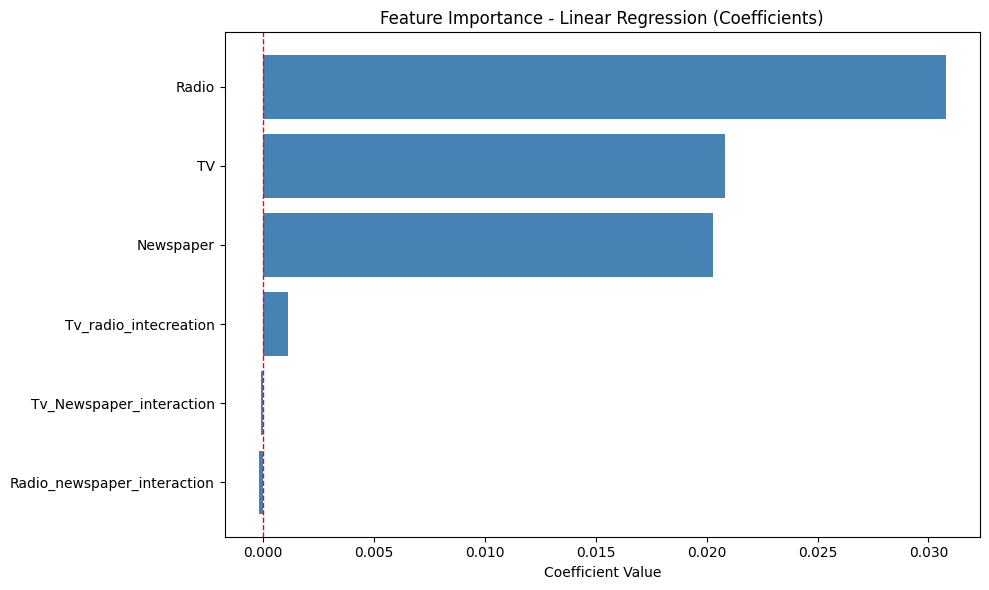

[ 2.08130183e-02  3.07770769e-02  2.02724178e-02  1.10378724e-03
 -7.89865425e-05 -1.85239376e-04]


In [45]:
importance = model.coef_

feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(feat_imp.index, feat_imp.values, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.title("Feature Importance - Linear Regression (Coefficients)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show() 

print(importance)

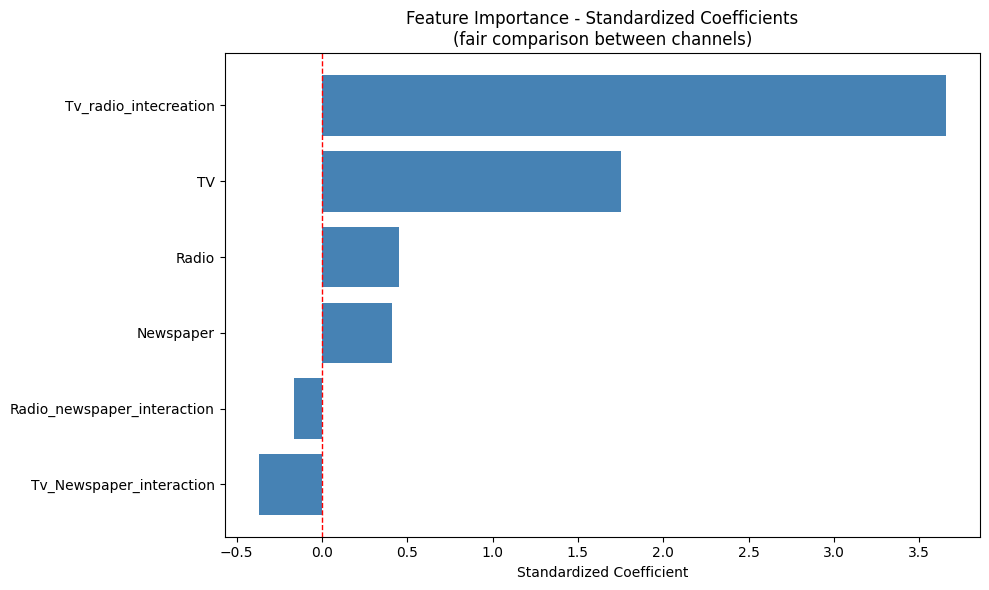

In [46]:
x_train_scaler = scaler.fit_transform(X_train) 
x_test_scaler = scaler.transform(X_test)

model_sc = LinearRegression() 
model_sc.fit(x_train_scaler , y_train)

feat_imp = pd.Series(model_sc.coef_ , index = features).sort_values() 
plt.figure(figsize=(10,6)) 
plt.barh(feat_imp.index , feat_imp.values , color = 'steelblue') 
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.title("Feature Importance - Standardized Coefficients\n(fair comparison between channels)")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

In [47]:
data['TV_efficiency'] = data['Sales'] / data['TV'] 
data['Radio_efficiency'] = data['Sales'] / data['Radio'] 
data['Newspaper_efficiency'] = data['Sales'] / data['Newspaper'] 

data['Total_Budget'] = data['TV'] + data['Radio'] + data['Newspaper'] 
data['TV_share'] = data['TV'] / data['Total_Budget'] 
data['Radio_share'] = data['Radio'] / data['Total_Budget'] 
data['Newspaper_share'] = data['Newspaper'] / data['Total_Budget']

In [48]:
data['TV_log']        = np.log1p(data['TV'])
data['Radio_log']     = np.log1p(data['Radio'])
data['Newspaper_log'] = np.log1p(data['Newspaper'])

In [49]:
data['TV_squared']    = data['TV'] ** 2
data['Radio_squared'] = data['Radio'] ** 2 
data['Newspaper_squared'] = data['Newspaper'] ** 2 

In [50]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales', 'tv_to_sales_ratio',
       'radio_to_sales_ratio', 'newspaper_to_sales_ratio', 'sales_level',
       'Tv_radio_intecreation', 'Tv_Newspaper_interaction',
       'Radio_newspaper_interaction', 'TV_Range', 'Newspaper_Range',
       'Radio_Range', 'TV_Radio_int', 'TV_Newspaper_int',
       'Newspaper_Radio_int', 'TV_efficiency', 'Radio_efficiency',
       'Newspaper_efficiency', 'Total_Budget', 'TV_share', 'Radio_share',
       'Newspaper_share', 'TV_log', 'Radio_log', 'Newspaper_log', 'TV_squared',
       'Radio_squared', 'Newspaper_squared'],
      dtype='object')

In [51]:
data.head()

,TV,Radio,Newspaper,Sales,tv_to_sales_ratio,radio_to_sales_ratio,newspaper_to_sales_ratio,sales_level,Tv_radio_intecreation,Tv_Newspaper_interaction,...,Total_Budget,TV_share,Radio_share,Newspaper_share,TV_log,Radio_log,Newspaper_log,TV_squared,Radio_squared,Newspaper_squared
0,230.1,37.8,69.2,22.1,10.411765,1.710407,3.131222,High,8697.78,15922.92,...,337.1,0.682587,0.112133,0.205280,5.442851,3.658420,4.251348,52946.01,1428.84,4788.64
1,44.5,39.3,45.1,10.4,4.278846,3.778846,4.336538,Medium_Low,1748.85,2006.95,...,128.9,0.345229,0.304888,0.349884,3.817712,3.696351,3.830813,1980.25,1544.49,2034.01
2,17.2,45.9,69.3,9.3,1.849462,4.935484,7.451613,Low,789.48,1191.96,...,132.4,0.129909,0.346677,0.523414,2.901422,3.848018,4.252772,295.84,2106.81,4802.49
3,151.5,41.3,58.5,18.5,8.189189,2.232432,3.162162,High,6256.95,8862.75,...,251.3,0.602865,0.164345,0.232789,5.027165,3.744787,4.085976,22952.25,1705.69,3422.25
4,180.8,10.8,58.4,12.9,14.015504,0.837209,4.527132,Medium_Low,1952.64,10558.72,...,250.0,0.723200,0.043200,0.233600,5.202907,2.468100,4.084294,32688.64,116.64,3410.56


In [53]:
features = [
    'TV', 'Radio', 'Newspaper',
    'Tv_radio_intecreation', 'Tv_Newspaper_interaction', 'Radio_newspaper_interaction',
    'Total_Budget', 'TV_share', 'Radio_share', 'Newspaper_share',
    'TV_log', 'Radio_log', 'Newspaper_log',
    'TV_squared', 'Radio_squared'
]

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)
pred = model.predict(X_test_sc)

print("R2  :", r2_score(y_test, pred))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2  : 0.9951272074939632
MAE : 0.3198950984984674
RMSE: 0.3921770557906092


In [ ]:
train_pred = model.predict(X_train_sc)
print("Train R2:", r2_score(y_train, train_pred))
print("Test  R2:", r2_score(y_test, pred))

Train R2: 0.9969359180400992
Test  R2: 0.9951272074939632


In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2')
print("CV R² scores:", cv_scores.round(4))
print("CV Mean     :", cv_scores.mean().round(4))
print("CV Std      :", cv_scores.std().round(4))

CV R² scores: [0.9947 0.9942 0.9974 0.997  0.9938]
CV Mean     : 0.9954
CV Std      : 0.0015


In [58]:
suspicious = ['Total_Budget', 'TV_share', 'Radio_share', 'Newspaper_share']

features_clean = [
    'TV', 'Radio', 'Newspaper',
    'Tv_radio_intecreation', 'Tv_Newspaper_interaction', 'Radio_newspaper_interaction',
    'TV_log', 'Radio_log', 'Newspaper_log',
    'TV_squared', 'Radio_squared'
]

X2 = data[features_clean]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)
X2_train_sc = scaler.fit_transform(X2_train)
X2_test_sc  = scaler.transform(X2_test)

model2 = LinearRegression()
model2.fit(X2_train_sc, y2_train)
pred2 = model2.predict(X2_test_sc)

print("\n without suspicious features:")
print("R2  :", r2_score(y2_test, pred2),4)
print("MAE :", mean_absolute_error(y2_test, pred2),4)
print("RMSE:", np.sqrt(mean_squared_error(y2_test, pred2)),4)


 without suspicious features:
R2  : 0.9952989992824683 4
MAE : 0.3150260553702357 4
RMSE: 0.3852018650871615 4


Our final model achieved an outstanding R² of 0.995 and a very low MAE of 0.31. Most importantly, the Cross-Validation confirmed the model's stability (Std: 0.0015). This proves that by using Interaction and Non-linear features (Log & Squared), we can accurately predict sales while maintaining a clean, robust feature set without any redundant or suspicious data."

In [61]:
data['TV_sqrt'] = np.sqrt(data['TV']) 
data['Radio_sqrt'] = np.sqrt(data['Radio']) 

data['TV_Radio_Newspaper'] = data['TV'] * data['Radio'] * data['Newspaper'] 

data['TV_tp_Radio_ratio'] = data['TV'] / (data['Radio'] + 1)

In [62]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales', 'tv_to_sales_ratio',
       'radio_to_sales_ratio', 'newspaper_to_sales_ratio', 'sales_level',
       'Tv_radio_intecreation', 'Tv_Newspaper_interaction',
       'Radio_newspaper_interaction', 'TV_Range', 'Newspaper_Range',
       'Radio_Range', 'TV_Radio_int', 'TV_Newspaper_int',
       'Newspaper_Radio_int', 'TV_efficiency', 'Radio_efficiency',
       'Newspaper_efficiency', 'Total_Budget', 'TV_share', 'Radio_share',
       'Newspaper_share', 'TV_log', 'Radio_log', 'Newspaper_log', 'TV_squared',
       'Radio_squared', 'Newspaper_squared', 'TV_sqrt', 'Radio_sqrt',
       'TV_Radio_Newspaper', 'TV_tp_Radio_ratio'],
      dtype='object')

In [65]:
fig = px.scatter(data, 
                x = 'TV_tp_Radio_ratio',
                y = 'Sales', 
                trendline = 'lowess',
                color_discrete_sequence = ['#636EFA'], 
                trendline_color_override = '#EF553B', 
                title = "Finding the Sweet Spot: TV to Radio Ratio vs Sales")

fig.update_layout(title_x=0.5, title_font_size=18, height=600)
fig.show()

In [66]:
feature_squared = ['TV_squared', 'Radio_squared', 'Newspaper_squared']

for x in feature_squared:
    fig = px.scatter(
        data, 
        x = x,
        y = 'Sales', 
        trendline = 'lowess',
        color = 'Sales', 
        color_continuous_scale = 'Viridis', 
        title = f'Impact of {x} on Sales (Non-linear View)'
    ) 
    fig.update_layout(title_x=0.5, title_font_size=18, height=500)
    fig.show()

In [68]:
feature_log = ['TV_log', 'Radio_log', 'Newspaper_log'] 
for x in feature_log :
    fig = px.scatter(
        data , 
        x = x , 
        y = 'Sales' , 
        trendline = 'lowess' , 
        color = 'Sales' ,
        color_continuous_scale= 'Viridis' , 
        title = f'Impact of {x} on Sales (Non - linear View)' 
    )
    fig.update_layout(title_x=0.5, title_font_size=18, height=500)
    fig.show()

In [69]:
data['Newspaper_sqrt'] = np.sqrt(data['Newspaper']) 

feature_sqrt = ['TV_sqrt', 'Radio_sqrt' , 'Newspaper_sqrt'] 
for x in feature_sqrt :
    fig = px.scatter(
        data , 
        x = x , 
        y = 'Sales' , 
        trendline = 'lowess' , 
        color = 'Sales' ,
        color_continuous_scale= 'Viridis' , 
        title = f'Impact of {x} on Sales (Non - linear View)' 
    )
    fig.update_layout(title_x=0.5, title_font_size=18, height=500)
    fig.show()

In [70]:
from sklearn.ensemble import RandomForestRegressor

X = data[features_clean] 
y = data['Sales'] 

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, random_state=42, test_size=0.2)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_r, y_train_r)

pred_rf = model_rf.predict(X_test_r)

print("R2 Score :", r2_score(y_test_r, pred_rf))
print("MAE      :", mean_absolute_error(y_test_r, pred_rf))
print("RMSE     :", np.sqrt(mean_squared_error(y_test_r, pred_rf)))

R2 Score : 0.9900464257179207
MAE      : 0.42672500000000024
RMSE     : 0.5605092104506406


In [73]:
importances = pd.Series(model_rf.feature_importances_, index=features_clean)
importances = importances.sort_values(ascending=False)

fig = px.bar(importances, x=importances.values, y=importances.index, orientation='h',
            title='Feature Importance: What drives Sales in Random Forest?',
            labels={'x': 'Importance Score', 'y': 'Features'})
fig.show() 

print(importances)

Tv_radio_intecreation          0.898458
TV                             0.034118
TV_squared                     0.031374
TV_log                         0.024263
Tv_Newspaper_interaction       0.005922
Newspaper_log                  0.001308
Newspaper                      0.001197
Radio_log                      0.000942
Radio_newspaper_interaction    0.000857
Radio                          0.000815
Radio_squared                  0.000747
dtype: float64


In [75]:
scores = cross_val_score(model_rf, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", scores)
print("Average R2:", scores.mean())

Cross-validation R2 scores: [0.99234795 0.9905556  0.98985898 0.97853686 0.98981919]
Average R2: 0.9882237162261795


In [77]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test_r, 
    y=pred_rf, 
    mode='markers',
    name='Predictions',
    marker=dict(color='#636EFA', opacity=0.7, size=10, line=dict(width=1, color='White'))
))
line_range = [min(y_test_r.min(), pred_rf.min()), max(y_test_r.max(), pred_rf.max())]
fig.add_trace(go.Scatter(
    x=line_range, 
    y=line_range, 
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='#EF553B', dash='dash', width=3)
))

fig.update_layout(
    title="<b>The Moment of Truth: Actual vs. Predicted Sales</b>",
    xaxis_title="Actual Sales",
    yaxis_title="Predicted Sales",
    title_x=0.5,
    height=600,
    template="plotly_white"
)

fig.show()

### 
Now that we've reached this stage, you can write the following summary in your notebook:

High Predictability: The model proved that the company's sales are highly predictable based on the advertising budget.

Synergy is Key: The interaction between TV and radio drives 90% of the results.

Efficiency: Newspaper ads are not contributing effectively, and their budget can be redirected to TV and radio to increase ROI.

Mathematical Fit: Using non-linear transformations was crucial for simulating reality, and the Random Forest confirmed this hypothesis.

In [79]:
import joblib

joblib.dump(model2, 'linear_advertising_model.pkl')

joblib.dump(model_rf, 'rf_advertising_model.pkl')

['rf_advertising_model.pkl']

In [80]:
data.to_csv('AD.csv')

In [82]:
scaler = StandardScaler()
X2_train_sc = scaler.fit_transform(X2_train) 
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']